# Classification after Clustering with Agglomerative Clustering

### Import CSV and Required Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report
from sklearn.model_selection import cross_val_score
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:
pd.pandas.set_option("display.max_columns",None)
df = pd.read_csv(r"./data/clustered_data.csv")
print(df.shape)


(2240, 22)


In [3]:
df

,Age,Education,Marital Status,Parental Status,Children,Income,Total_Spending,Days_as_Customer,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,Web,Catalog,Store,Discount Purchases,Total Promo,NumWebVisitsMonth,cluster
0,65,2,0,0,0,58138.0,1617.0,3860,58,635,81,546,120.5,81,88.0,8,10,4,3,0,7,0
1,68,2,0,1,2,46344.0,27.0,3014,38,11,1,6,2.0,1,6.0,1,1,2,2,0,5,2
2,57,2,1,0,0,71613.0,776.0,3361,26,426,49,127,111.0,21,42.0,8,2,10,1,0,4,0
3,38,2,1,1,1,26646.0,53.0,2954,26,11,4,20,10.0,3,5.0,2,0,4,2,0,6,2
4,41,4,1,1,1,58293.0,422.0,3210,94,173,43,118,46.0,27,15.0,5,3,6,5,0,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,55,2,1,1,1,61223.0,1341.0,3430,46,709,43,182,42.0,81,126.5,9,3,4,2,0,5,1
2236,76,4,1,1,3,64014.0,444.0,2950,56,406,0,30,0.0,0,8.0,8,2,5,7,1,7,1
2237,41,2,0,0,0,56981.0,1241.0,3204,91,908,48,217,32.0,12,24.0,2,3,13,1,1,6,0
2238,66,3,1,1,1,69245.0,843.0,3205,8,428,30,214,80.0,30,61.0,6,5,10,2,0,3,0


In [37]:
df.columns

Index(['Age', 'Education', 'Marital Status', 'Parental Status', 'Children',
       'Income', 'Total_Spending', 'Days_as_Customer', 'Recency', 'Wines',
       'Fruits', 'Meat', 'Fish', 'Sweets', 'Gold', 'Web', 'Catalog', 'Store',
       'Discount Purchases', 'Total Promo', 'NumWebVisitsMonth', 'cluster'],
      dtype='str')

**Split X and y**
- Why do we split our data?
> Training Dataset is the part of Original Dataset that we use to train our ML model. The model learns on this data by running the algorithm and maps a function F(x) where “x” in the independent variable (inputs) for “y” where “y” is the dependent variable(output).

In [4]:
X = df.drop("cluster",axis=1)#dropping the target column which is "cluster"
Y = df["cluster"]

In [39]:
X

,Age,Education,Marital Status,Parental Status,Children,Income,Total_Spending,Days_as_Customer,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,Web,Catalog,Store,Discount Purchases,Total Promo,NumWebVisitsMonth
0,65,2,0,0,0,58138.0,1617.0,3860,58,635,81,546,120.5,81,88.0,8,10,4,3,0,7
1,68,2,0,1,2,46344.0,27.0,3014,38,11,1,6,2.0,1,6.0,1,1,2,2,0,5
2,57,2,1,0,0,71613.0,776.0,3361,26,426,49,127,111.0,21,42.0,8,2,10,1,0,4
3,38,2,1,1,1,26646.0,53.0,2954,26,11,4,20,10.0,3,5.0,2,0,4,2,0,6
4,41,4,1,1,1,58293.0,422.0,3210,94,173,43,118,46.0,27,15.0,5,3,6,5,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,55,2,1,1,1,61223.0,1341.0,3430,46,709,43,182,42.0,81,126.5,9,3,4,2,0,5
2236,76,4,1,1,3,64014.0,444.0,2950,56,406,0,30,0.0,0,8.0,8,2,5,7,1,7
2237,41,2,0,0,0,56981.0,1241.0,3204,91,908,48,217,32.0,12,24.0,2,3,13,1,1,6
2238,66,3,1,1,1,69245.0,843.0,3205,8,428,30,214,80.0,30,61.0,6,5,10,2,0,3


## Grid Search

- Why do we use Grid Search?

`GridSearchCV` is a technique to search through the best parameter values from the given set of the grid of parameters. It is basically a cross-validation method. the model and the parameters are required to be fed in. Best parameter values are extracted and then the predictions are made.

## Select the best model
- so here we have some list of the best classification algorithms we imported. Now we will compare each model's score and see which model is performing better than rest of the others

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,classification_report, ConfusionMatrixDisplay,precision_score, recall_score,f1_score,roc_auc_score,roc_curve,confusion_matrix

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn import metrics

In [6]:
# !pip install catboost

In [7]:
models = {
    "Random Forest" : RandomForestClassifier(),
    "Decision Tree" : DecisionTreeClassifier(),
    "Gradient Boosting" : GradientBoostingClassifier(),
    "Logistic Regression" : LogisticRegression(),
    "K-Neighbors Classifier" : KNeighborsClassifier(),
    "XGBClassifier" : XGBClassifier(),
    "CatBoosting Classifier" : CatBoostClassifier(verbose=False),
    "AdaBoost Classifier" : AdaBoostClassifier()
}

- ### We will create a generic function to check each model's performance so that we can compare those

In [8]:
# Create a functionwhich can evaluate models and return a report
def evaluate_models(X,Y,models):
    '''
    This function takes in  x and y and model dictionary as imput
    It splits the data into Train Test Split
    Iterates through the given model dictionary and evaluates the metrics
    Return : DataFrame which contains report of all models metrics with cost
    '''

    # seprate dataset into train and test
    X_train , X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.3,random_state=1)

    models_list = []
    scores = []

    for i in range(len(list(models))):
        model = list(models.values())[i]
        model.fit(X_train,Y_train)#Train model

        # make predictions
        Y_pred = model.predict(X_test)
        score = accuracy_score(Y_test,Y_pred)

        model_name = list(models.keys())[i]
        print(f"---- score for ----{model_name}----")
        print(f"{score}")
        models_list.append(model_name)
        scores.append(score)
    print()
    report = pd.DataFrame()
    report["Model_name"] = models_list
    report["Score"] = scores
    return report

### Let's check the report

In [9]:
report = evaluate_models(X,Y,models)

---- score for ----Random Forest----
0.9583333333333334
---- score for ----Decision Tree----
0.9285714285714286
---- score for ----Gradient Boosting----
0.96875
---- score for ----Logistic Regression----
0.8675595238095238
---- score for ----K-Neighbors Classifier----
0.8080357142857143
---- score for ----XGBClassifier----
0.96875
---- score for ----CatBoosting Classifier----
0.9672619047619048
---- score for ----AdaBoost Classifier----
0.9538690476190477



In [10]:
report

,Model_name,Score
0,Random Forest,0.958333
1,Decision Tree,0.928571
2,Gradient Boosting,0.968750
3,Logistic Regression,0.867560
4,K-Neighbors Classifier,0.808036
5,XGBClassifier,0.968750
6,CatBoosting Classifier,0.967262
7,AdaBoost Classifier,0.953869


In [11]:
report.sort_values("Score")

,Model_name,Score
4,K-Neighbors Classifier,0.808036
3,Logistic Regression,0.867560
1,Decision Tree,0.928571
7,AdaBoost Classifier,0.953869
0,Random Forest,0.958333
6,CatBoosting Classifier,0.967262
2,Gradient Boosting,0.968750
5,XGBClassifier,0.968750


- ### From the report above we can see that the XGBClassifier model performed the best, so we will continue training our model using XGBClassifier algorithm.

### Split into Train and test data

- **Do you know why we split the train and test dataset?**
> The train test split technique can be used for classification and regression problems to test machine learning algorithms. The procedure takes the given dataset and splits it into two subsets: ```Training data/train set:``` it is used to train the algorithm and fit the machine learning model
then we have ```test data/test set``` which is basically a different data for which we know the values but this data was never shown to the model before. Thus if the model after training is performing good on test set as well then we can say that the Machine Learning model is good.

In [12]:
# separate data into trian and test sets
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,random_state=1,test_size=0.3)
X_train

,Age,Education,Marital Status,Parental Status,Children,Income,Total_Spending,Days_as_Customer,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,Web,Catalog,Store,Discount Purchases,Total Promo,NumWebVisitsMonth
1747,76,3,1,0,0,66835.0,1033.0,3323,21,620,26,195,34.0,17,126.5,6,4,13,1,0,2
115,60,2,0,1,2,50785.0,114.0,3312,27,64,1,21,0.0,1,27.0,2,1,3,2,0,6
1739,51,4,1,1,1,42403.0,42.0,3278,18,22,1,11,0.0,5,3.0,1,0,3,1,0,8
336,54,2,0,0,0,75693.0,1442.0,3796,10,797,81,293,72.0,81,30.0,11,4,6,1,3,4
2031,67,2,1,1,1,67225.0,868.0,3264,4,315,35,322,46.0,7,126.5,7,2,11,3,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
960,55,2,0,1,1,70647.0,1079.0,3695,65,561,81,171,25.0,81,114.0,4,7,13,2,0,2
905,45,2,0,0,0,85072.0,1423.0,2982,94,494,81,391,120.5,11,126.5,3,4,10,1,0,0
1096,64,2,0,1,1,79803.0,868.0,3192,54,574,8,216,21.0,16,33.0,4,3,5,1,0,1
235,47,1,1,1,1,22212.0,69.0,3339,49,5,9,20,6.0,8,21.0,2,0,4,2,0,6


In [13]:
X_test

,Age,Education,Marital Status,Parental Status,Children,Income,Total_Spending,Days_as_Customer,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,Web,Catalog,Store,Discount Purchases,Total Promo,NumWebVisitsMonth
779,51,2,0,1,1,72258.0,1525.0,3251,28,522,0,522,120.5,81,126.5,6,9,5,2,0,2
389,54,4,0,1,2,83664.0,1173.0,3377,57,866,21,151,28.0,21,86.0,2,2,12,3,0,5
510,41,4,1,1,1,39665.0,216.0,3449,97,127,1,56,0.0,1,31.0,4,2,3,3,1,7
1553,60,2,1,0,0,76081.0,1033.0,3086,85,292,30,415,63.0,33,126.5,4,5,4,1,1,2
1172,32,4,1,0,0,74214.0,1711.0,3721,3,863,81,547,86.0,81,33.0,8,2,5,1,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,58,2,1,1,2,48920.0,347.0,3301,93,238,17,68,8.0,10,6.0,6,2,5,3,1,7
536,55,2,1,1,1,44931.0,96.0,3211,0,78,0,11,0.0,0,7.0,2,1,3,1,0,5
1094,57,4,1,1,2,57236.0,121.0,2892,22,105,0,9,2.0,1,4.0,2,1,4,3,0,3
1999,42,1,0,1,1,67506.0,331.0,3197,73,90,38,67,33.0,36,67.0,4,1,6,1,0,3


### Let's do hyperparameter tuning
- **And what's it actually?**

> A Machine Learning model is defined as a mathematical model with a number of parameters that need to be learned from the data. By training a model with existing data, we are able to fit the model parameters. 
However, there is another kind of parameter, known as Hyperparameters, that cannot be directly learned from the regular training process. They are usually fixed before the actual training process begins. These parameters express important properties of the model such as its complexity or how fast it should learn. 

In [14]:
xgb = XGBClassifier(
    objective = "binary:logistic",
    eval_metrics = "logloss",
    use_lavel_encoder = False
)

In [15]:
xgb.fit(X_train,Y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [16]:
Y_pred = xgb.predict(X_test)
Y_pred

array([0, 1, 2, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 2, 0, 2, 1,
       1, 2, 2, 0, 1, 1, 2, 1, 1, 2, 2, 0, 0, 0, 2, 2, 1, 1, 1, 0, 2, 0,
       1, 0, 1, 1, 2, 1, 2, 0, 2, 1, 2, 0, 1, 2, 0, 2, 2, 0, 0, 1, 1, 2,
       2, 2, 2, 1, 2, 1, 2, 0, 2, 2, 1, 1, 0, 2, 0, 1, 2, 2, 0, 2, 1, 1,
       1, 2, 1, 0, 1, 2, 1, 0, 2, 1, 2, 1, 0, 0, 2, 2, 1, 1, 2, 0, 2, 2,
       1, 2, 1, 0, 0, 1, 0, 1, 2, 2, 2, 1, 1, 0, 1, 2, 0, 1, 2, 0, 2, 1,
       1, 0, 1, 2, 1, 1, 0, 0, 0, 1, 2, 1, 1, 1, 2, 0, 0, 1, 1, 2, 0, 2,
       0, 1, 0, 2, 0, 2, 2, 2, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 2, 1, 2, 2,
       1, 2, 1, 2, 0, 2, 1, 2, 1, 0, 0, 2, 2, 2, 1, 0, 0, 0, 0, 2, 2, 0,
       0, 2, 2, 2, 2, 2, 2, 2, 1, 0, 2, 1, 1, 2, 1, 1, 1, 2, 1, 0, 1, 2,
       0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 2, 0, 1, 2, 2, 0, 1, 0, 2,
       0, 2, 2, 2, 0, 0, 2, 1, 0, 0, 2, 2, 2, 2, 1, 2, 2, 2, 2, 1, 2, 1,
       2, 2, 0, 0, 1, 2, 1, 2, 2, 2, 1, 1, 2, 0, 1, 1, 2, 0, 2, 2, 0, 0,
       1, 0, 2, 2, 0, 1, 2, 1, 1, 2, 0, 0, 1, 0, 2,

In [17]:
accuracy_score(Y_test,Y_pred)

0.96875

In [18]:
train_acc = accuracy_score(Y_train,xgb.predict(X_train))
test_acc = accuracy_score(Y_test, xgb.predict(X_test))
print("Train ACC : ",train_acc)
print("Test Acc : ",test_acc)

Train ACC :  1.0
Test Acc :  0.96875


In [19]:
# Grid search cross validation
from sklearn.model_selection import GridSearchCV

params = {
    "n_estimators" : [100,200,300],
    "max_depth" : [3,5,7],
    "learning_rate":[0.01,0.05,0.1],
    # "subsample" : [0.7,0.8,1],
    # "colsample_bytree" : [0.7,0.8,1],
    "gamma":[0,0.1,0.3],
    "reg_alpha" : [0,0.1,1],#Tune regularization
    "reg_lambda" : [1,1.5,2]#Tune regularization
}

In [20]:
grid = GridSearchCV(
    estimator=xgb,
    param_grid=params,
    cv = 5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=3
)

In [21]:
grid.fit(X_train, Y_train)

Fitting 5 folds for each of 729 candidates, totalling 3645 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...obs=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and 

In [22]:
print("Best Cross Validation Accuracy : ")
print(grid.best_score_)

Best Cross Validation Accuracy : 
0.9661952341222199


In [23]:
best_model = grid.best_estimator_
Y_pred_best_model = best_model.predict(X_test)

In [24]:
accuracy_score(Y_test,Y_pred_best_model)

0.9657738095238095

In [25]:
train_acc = accuracy_score(Y_train,best_model.predict(X_train))
test_acc = accuracy_score(Y_test,best_model.predict(X_test))
print("Train acc : ",train_acc)
print("Test acc : ",test_acc)

Train acc :  1.0
Test acc :  0.9657738095238095


In [26]:
print(classification_report(Y_test,Y_pred_best_model))

              precision    recall  f1-score   support

           0       0.97      0.93      0.95       174
           1       0.93      0.97      0.95       220
           2       0.99      0.99      0.99       278

    accuracy                           0.97       672
   macro avg       0.96      0.96      0.96       672
weighted avg       0.97      0.97      0.97       672



In [27]:
print("Best Parameters : ")
print(grid.best_params_)

Best Parameters : 
{'gamma': 0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'reg_alpha': 0.1, 'reg_lambda': 1.5}


In [28]:
best_Xgb_model = XGBClassifier(
    gamma = 0,
    n_estimators = 200,
    learning_rate = 0.05,
    max_depth = 3,
    reg_alpha = 0.1,
    reg_lambda = 1.5
)

**Initialize model with best parameters**
### Let's check the report now

In [29]:
XGB_Model = best_Xgb_model.fit(X_train,Y_train)
XGB_Y_pred = XGB_Model.predict(X_test)
score = accuracy_score(Y_test,XGB_Y_pred)
cr = classification_report(Y_test,XGB_Y_pred)

print("XGB Classifier")
print("Accuracy Score value : ",score)
print(cr)

XGB Classifier
Accuracy Score value :  0.9657738095238095
              precision    recall  f1-score   support

           0       0.97      0.93      0.95       174
           1       0.93      0.97      0.95       220
           2       0.99      0.99      0.99       278

    accuracy                           0.97       672
   macro avg       0.96      0.96      0.96       672
weighted avg       0.97      0.97      0.97       672



## Confusion matrix of the model
- **What is confusion matrix ?**
> The confusion matrix is a matrix used to determine the performance of the classification models for a given set of test data. It can only be determined if the true values for test data are known. The matrix itself can be easily understood, but the related terminologies may be confusing.

In [30]:
print(confusion_matrix(Y_test,XGB_Y_pred))

[[162  11   1]
 [  5 213   2]
 [  0   4 274]]


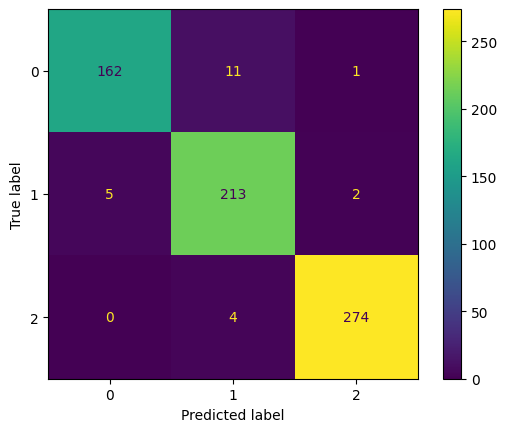

In [31]:
ConfusionMatrixDisplay.from_estimator(best_model,X_test,Y_test)

- **Reports**

**We can see, that the model performed pretty well.**
- we have used XGBoost Classifier as it performed well than other models
- We got a good accuracy while predicting the test dataset.

In [ ]:
# import joblib
# import os
# os.makedirs("../models",exist_ok=True)
# joblib.dump(XGB_Model,"../models/customer_classifier.pkl")
# print("Model saved successfully")

Model saved successfully


In [42]:
print(XGB_Model.feature_importances_)

[0.00997489 0.0045721  0.00422892 0.260862   0.01574336 0.03657655
 0.2843167  0.00506541 0.00762969 0.01609054 0.03087432 0.04668908
 0.02601543 0.01714747 0.00420823 0.00673295 0.10240413 0.00735772
 0.07477882 0.00514114 0.03359056]
